(sec-pypckg)=
# Paquets, modules et bibliothèques

Import external libraries and organize your code into functional chunks. For interactive reading and executing code blocks [![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/hydro-informatics/jupyter-python-course/main) and find *b05-pypckg.ipynb*, or install {ref}`Python <install-python>` and {ref}`JupyterLab <jupyter>` locally.

```{admonition} Requirements
Assurez-vous de comprendre {ref}`Python functions <chpt-functions>`.
```

```{admonition} Watch this section as a video
:class: tip, dropdown
<iframe width="701" height="394" src="https://www.youtube-nocookie.com/embed/-bM4kfNbZe4" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe>
<p>Watch this section as a video on the <a href="https://www.youtube.com/@hydroinformatics">@Hydro-Morphodynamics channel on YouTube</a>.</p>
```

## Importer des paquets ou des modules

L'importation d'un paquet ou d'un module dans Python rend les fonctions externes et d'autres éléments (tels que les objets) des modules accessibles dans un script. Les fonctions et autres éléments sont stockés dans un autre fichier Python (`.py`) dans certains dossiers */site packages/* (répertoire) des environnements interprètes. Ainsi, pour utiliser un paquet non standard, il doit d'abord être téléchargé et installé. Les paquets Python standard (par exemple, `os`, `math`) sont toujours accessibles, et d'autres peuvent être ajoutés avec *conda* ou *pip* ({ref}`read more pip-installing <install-pckg>`).

```{admonition} The Difference between a Module and a Package
Les modules sont des fichiers simples ou multiples qui peuvent être importés indépendamment (p. ex. importer un script nommé `a_module.py` avec `import a_module`). Les paquets sont une collection de modules dans un répertoire avec une hiérarchie définie, ce qui permet également l'importation de modules individuels (par exemple `from a_package.module import a_function`). Les paquets sont donc aussi des modules, mais avec une définition hiérarchique (c.-à-d. un attribut `__path__` et un fichier `__init__.py`). Ça a l'air flou ? Lire cette section en bas et revenir ici pour relire cette note.
```

Le paquet `os` fournit des commandes de base de type système-terminal, par exemple, pour gérer les répertoires de dossiers. Importons donc ce paquet essentiel :

In [1]:
import os
print(os.getcwd()) # print current working directory
print(os.path.abspath('')) # print directory of script running

/home/schwindt/github/hyhome-v2/jupyter
/home/schwindt/github/hyhome-v2/jupyter


### Aperçu des options d'importation

Voici un aperçu des options pour importer des paquets ou des modules (parties hiérarchiques des paquets):

| Command | Description | Usage of attributes |
|---------|-------------|---------------------|
| `import package-name` | Import an original module | `package.item()` |
| `import package-name as nick-name` | Import module and rename (alias) it in the script |  `nick-name.item()` |
| `from package-name import item` | Import only a function, class or other items |  `item()` |
| `from package-name import *` | Import all items |  `item()` |


### Exemple

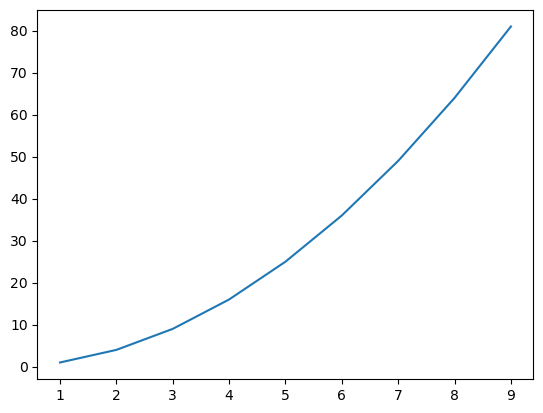

In [2]:
import matplotlib.pyplot as plt # import pyplot from the matplotlib module and alias it with plt
import math as m

x = []
y = []

for e in range(1, 10):
    x.append(e)
    y.append(e**2)

plt.plot(x, y)

### Quelle est la meilleure façon d'importer un paquet ou un module?
Il n'y a pas de réponse globale à cette question. Cependant, sachez que `from package-name import *` écrase toute variable existante ou tout autre élément du script. Ainsi, n'utilisez `*` que lorsque vous connaissez tout le contenu d'un module ou d'un paquet.

In [3]:
pi = 9.112 # define a float called pi 
print("Pi is not %1.3f." % pi)

from math import pi # this overwrites the before defined variable pi
print("Pi is %1.3f." % pi)

Pi is not 9.112.
Pi is 3.142.


```{tip}
Définissez les paquets d'importation par défaut pour le noyau *IPython* de *JupyterLab* (lisez plus dans {ref}`Python installation section <ipython-config>`).
```

### Quels sont les éléments (attributs, classes, fonctions) dans un module?

Parfois, nous voulons explorer des modules ou vérifier des attributs variables. Ceci est réalisé avec la commande `dir()`:

In [4]:
import sys
print(sys.path)
print(dir(sys.path))

a_string = "zabaglione"
print(", ".join(dir(a_string)))

['/home/schwindt/miniforge3/envs/wrr-proj/lib/python311.zip', '/home/schwindt/miniforge3/envs/wrr-proj/lib/python3.11', '/home/schwindt/miniforge3/envs/wrr-proj/lib/python3.11/lib-dynload', '', '/home/schwindt/miniforge3/envs/wrr-proj/lib/python3.11/site-packages']
['__add__', '__class__', '__class_getitem__', '__contains__', '__delattr__', '__delitem__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__imul__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__mul__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__reversed__', '__rmul__', '__setattr__', '__setitem__', '__sizeof__', '__str__', '__subclasshook__', 'append', 'clear', 'copy', 'count', 'extend', 'index', 'insert', 'pop', 'remove', 'reverse', 'sort']
__add__, __class__, __contains__, __delattr__, __dir__, __doc__, __eq__, __format__, __ge__, __getattribute__, __getitem__, __getnewar

(make-mod)=
## Créer un nouveau module

Dans la programmation orientée objet et la factorisation de code, l'écriture personnalisée, de nouveaux modules est une tâche essentielle. Pour écrire un nouveau module, créez d'abord un nouveau script. Ensuite, ouvrez le nouveau script et ajoutez quelques paramètres et fonctions.

In [5]:
# icecreamdialogue.py
flavors = ["vanilla", "chocolate", "bread"]
price_scoops = {1: "two euros", 2: "three euros", 3: "your health"}
welcome_msg = "Hi, I only have " + flavors[0] + ". How many scoops do you want?"

[`icecreamdialogue.py`](https://github.com/hydro-informatics/icecream/raw/master/single-scripts/icecreamdialogue.py) can now either be executed as a script (nothing will happen visibly) or imported as a module to access its variables (e.g., `icecreamdialogue.flavors`):

In [ ]:
import icecreamdialogue as icd
print(icd.welcome_msg)
scoops_wanted = 2
print("That makes {0} please".format(icd.price_scoops[scoops_wanted]))

(standalone)=
### Faites du script autonome

As an alternative, we can append the call to items in [`icecreamdialogue.py`](https://github.com/hydro-informatics/icecream/raw/master/single-scripts/icecreamdialogue.py) in the script and run it as a stand-alone script by adding an `if __name__ == "__main__":` block:

In [6]:
# icecreamdialogue_standalone.py
flavors = ["vanilla", "chocolate", "bread"]
price_scoops = {1: "two euros", 2: "three euros", 3: "your health"}
welcome_msg = "Hi, I only have " + flavors[0] + ". How many scoops do you want?"


if __name__ == "__main__":
    print(welcome_msg)
    scoops_wanted = 2
    print("That makes {0} please".format(price_scoops[scoops_wanted]))

Hi, I only have vanilla. How many scoops do you want?
That makes three euros please


Now we can run [`icecreamdialogue_standalone.py`](https://github.com/hydro-informatics/icecream/raw/master/single-scripts/icecreamdialogue_standalone.py) in a terminal (e.g., Linux Terminal, PyCharm's Terminal tab at the bottom of the window, or VS Code's integrated terminal).

```
C:\temp\ python icecreamdialogue_standalone.py
```

```{note}
Selon la définition des variables système utilisée dans l'environnement *Terminal*, Python doit être appelé avec un nom variable différent de `python` (par exemple, `python3` sur certaines plateformes Linux).
```

(standaloneplus)=
### Scripts autonomes avec paramètres d'entrée

Pour rendre le script plus flexible, nous pouvons définir, par exemple, `scoops_wanted` comme variable d'entrée d'une fonction.

```python
# icecreamdialogue_standalone_withinput.py
flavors = ["vanilla", "chocolate", "bread"]
price_scoops = {1: "two euros", 2: "three euros", 3: "your health"}
welcome_msg = "Hi, I only have " + flavors[0] + ". How many scoops do you want?"

def dialogue(scoops_wanted): #formerly in the __main__ statement
    print(welcome_msg)
    print("That makes {0} please".format(price_scoops[scoops_wanted]))

if __name__ == "__main__":
    # import the terminal function emulator sys
    import sys
    if len(sys.argv) > 1: # make sure input is provided
        # if true: call the dialogue function with the input argument
        dialogue(int(sys.argv[1]))
```

Maintenant, nous pouvons lancer `icecreamdialogue_standalone_withinput.py` dans un terminal.


```
C:\temp\ python3 icecreamdialogue_standalone.py 2
```

(make-pckg)=
### Initialisation d'un paquet (module organisé de façon hiérarchisée)

La bonne pratique implique qu'un script ne dépasse pas 50 à 100 lignes de code (sauf les documents en ligne et les variables multilignes). En conséquence, un paquet sera probablement composé de plusieurs scripts qui sont stockés dans un dossier et un script de base sert pour l'initiation des scripts. Ce script principal s'appelle `__init__.py` et Python invoquera toujours ce nom de script dans un dossier de paquetage. Exemple de structure d'un module appelé `icecreamery`:

* `icecreamery` (nom du dossier)
  - `__init__.py` - initiation du paquet * script Python*
  - `icecreamdialogue.py` - dialogue produisant le script *Python*
  - `icecream_maker.py` - production de crème glacée virtuelle * script Python*

Pour invoquer automatiquement les deux scripts pertinents (sous-modules) du module `icecreamery`, le `__init__.py` doit inclure les éléments suivants :

In [ ]:
# __init__.py
print(f'Invoking __init__.py for {__name__}') # not absolutely needed ..
import icecreamery.icecreamdialogue, icecreamery.icecream_maker

In [ ]:
# example usage of the icecreamery package
import icecreamery
print(icecreamery.icecreamdialogue.welcome_msg)

Vous souvenez-vous de la fonction `dir()`? Il est destiné à énumérer tous les modules dans un paquet, mais il ne le fait pas à moins que nous définissions une liste `__all__` dans le `__init__.py`.

```python
# __init__.py with __all__ list
__all__ = ['icecreamdialogue', 'icecream_maker']
```

L'exemple complet du paquet `icecreamery_all` est également disponible dans un dépôt [icecream](https://github.com/hydro-informatics/icecream).

In [ ]:
# example usage of the icecreamery package
from icecreamery_all import *
print(icecreamdialogue.welcome_msg)

### Sommaire de la création du paquet

Un paquet hiérarchiquement organisé contient un fichier `__init__.py` avec une liste `__all__` pour invoquer les scripts de module pertinents. La structure d'un module peut être plus complexe que la liste d'exemples ci-dessus (par exemple, avec des sous-dossiers). Lorsque vous écrivez un paquet, pensez à utiliser {ref}`meaningful script and variable names <libs>`, avec la documentation appropriée.

```{admonition} Exercise with logging
Mettre en place un {ref}`logger <logging>` personnalisé dans votre module avec `logger = logging.getLogger(__name__)` (remplacez `__name__` par exemple `my-module-log`).
```

## Recharger (réimporter) un paquet ou un module

Depuis Python3, recharger un module nécessite d'importer le module `importlib`. Recharger n'a de sens que si vous écrivez activement un nouveau module. Pour recharger n'importe quel type de module :

```python
import importlib
importlib.reload(my_module)
```

## Vérification de la réussite en apprentissage

Prenez le [test de réussite d'apprentissage pour ce carnet Jupyter](https://forms.gle/jK3ttvKJ3xzsAWSp6).

````{admonition} Unfold QR Code
:class: tip, dropdown

```{image} ../img/qr-codes/gle-pypkg.png
```
````